In [145]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 


In [146]:
preds_dir = '../preds/'
dataset_dir = '../data/'

SCALING_FACTOR = 2
YEAR = 1984

In [147]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)

In [148]:
files = os.listdir(preds_dir)
print(files)

['output_1984_4x.pt', 'EDSR_1984_2x.pt', 'output_1984_2x.pt', 'baseline_1984_2x.pt', 'baseline_1984_4x.pt', 'baseline_1984_8x.pt']


# Ground Truth

In [149]:
dataset = load_dataset(dataset_dir + 'era5_training.nc',
                       start='1980-01-01', 
                       end='1984-12-31', 
                       patch_size=32)

train_split = dataset.sel(valid_time=slice('1980-01-01', '1982-12-31'))
eval_split = dataset.sel(valid_time=slice('1984-01-01', '1984-12-31'))

_, scale = normalize_data(train_split)
#eval_split, _ = normalize_data(eval_split, scale)
print(scale)
#gstack first two channels in a tensor+
eval_split_tensor = torch.stack([torch.tensor(eval_split[var].values) for var in eval_split.data_vars], dim=1)
print(eval_split_tensor.shape)
ground_truth_wind_speeds = np.sqrt(eval_split['u10'].values**2 + eval_split['v10'].values**2)
print(ground_truth_wind_speeds.shape)


{'u10': {'min': np.float32(-15.279355), 'max': np.float32(24.534174)}, 'v10': {'min': np.float32(-16.699005), 'max': np.float32(21.35775)}, 'd2m': {'min': np.float32(245.78934), 'max': np.float32(296.0891)}, 't2m': {'min': np.float32(248.4476), 'max': np.float32(306.05835)}, 'msl': {'min': np.float32(96446.56), 'max': np.float32(104656.41)}, 'tp': {'min': np.float32(0.0), 'max': np.float32(0.01362586)}}
torch.Size([1464, 6, 32, 32])
(1464, 32, 32)


# Low res input

In [150]:
u10 = []
v10 = []
for i in range(eval_split['u10'].shape[0]):
    u10.append(average_pooling(eval_split['u10'][i].values, SCALING_FACTOR, False))
    v10.append(average_pooling(eval_split['v10'][i].values, SCALING_FACTOR, False))
u10 = np.array(u10)
v10 = np.array(v10)
# get wind speed
lr_wind_speeds = np.sqrt(u10**2 + v10**2)

print(lr_wind_speeds.shape)




(1464, 16, 16)


# Model Output

In [ ]:
ws_fields = [lr_wind_speeds, ground_truth_wind_speeds]
names = ["LR Input", "HR Ground Truth"]
print(SCALING_FACTOR)
for file in files:
    #get specific file name
    if not file.endswith(f'{SCALING_FACTOR}x.pt'):
        continue
    field = torch.load(preds_dir + file, weights_only=False)
    print("Current file: ", file)   
    if file == f'baseline_{YEAR}_{SCALING_FACTOR}x.pt':
        baseline = get_original_wind_speed(field, scale)
        names.append("Bilinear Interpolation")
       
        ws_fields.append(baseline)
    elif file == f'EDSR_{YEAR}_{SCALING_FACTOR}x.pt':
        names.append("EDSR")
        edsr = get_original_wind_speed(field, scale)
        ws_fields.append(edsr)
    


2
Current file:  EDSR_1984_2x.pt
Current file:  output_1984_2x.pt
Current file:  baseline_1984_2x.pt


# Compare 


437


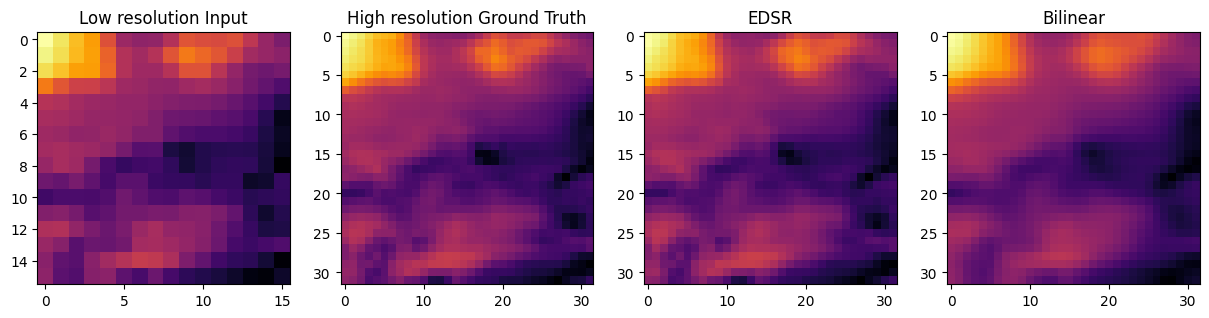

In [152]:
def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 6))
    fields = [field[index] for field in fields]
    for i, field in enumerate(fields):
        ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        
    plt.show()

index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, index)
